# 🏥 Prédiction Hiérarchique — Domaine → Service → ESI

Ce notebook implémente une **chaîne de prédiction en 3 étapes** :

| Étape | Cible | Description |
|---|---|---|
| **1** | `Domaine` | Grande catégorie médicale (ex: Médecine, Chirurgie…) |
| **2** | `Service` | Service précis d'admission (30 services) |
| **3** | `ESI` | Score de triage d'urgence (1 = critique → 5 = non urgent) |

**Logique :** Le domaine prédit enrichit la prédiction du service, et le service prédit enrichit la prédiction de l'ESI. Chaque étape utilise la sortie des précédentes comme feature supplémentaire.

**Modèles entraînés :** Random Forest · XGBoost · DNN (réseau de neurones dense)

---

In [1]:
! pip install python3.11 -m pip install ipykernel --break-system-packages


Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -m


## 📦 1. Importation des librairies

In [2]:
# ── Installation (à lancer une seule fois) ──────────────────────────────────
!pip install xgboost scikit-learn pandas numpy openpyxl  seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install pandas joblib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install scipy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# ── Librairies standard ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import scipy.sparse as sp
import warnings, os, joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.base              import BaseEstimator, TransformerMixin
from sklearn.metrics           import (
    classification_report, accuracy_score, f1_score, confusion_matrix
)

# ── XGBoost ──────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── TensorFlow / Keras (DNN) ──────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ Librairies importées | TF {tf.__version__}')

I0000 00:00:1779192377.252938  105204 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779192377.253378  105204 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779192377.546404  105204 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779192379.458700  105204 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

✅ Librairies importées | TF 2.21.0


## 📂 2. Chargement & exploration des données

In [7]:
# ⚠️ Modifier le chemin si nécessaire
DATA_PATH = 'dataset_v4_triage_complet.xlsx'

df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   Colonnes : {df.columns.tolist()}')
print(f'\n📊 Valeurs manquantes :')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
df.head(3)

✅ Dataset chargé : 33950 lignes × 11 colonnes
   Colonnes : ['date', 'ndm', 'age', 'sexe', 'service', 'visite', 'subject', 'object', 'ESI', 'Domaine', 'lieu']

📊 Valeurs manquantes :
date    2982
ndm     2982
lieu     132


,date,ndm,age,sexe,service,visite,subject,object,ESI,Domaine,lieu
0,2023-12-28 00:00:00,125558.0,0.0,Féminin,Traumato,Visite ultérieure,MC(Motif de Consultation): polytraumatisme AVP...,convulsions actives lors de l'examen TA(Tensio...,1,Chirurgie et spécialités chirurgicales,Kadiogo
1,2023-12-28 00:00:00,118389.0,51.0,Féminin,Traumato,Visite ultérieure,patiente vue pour douleur du coude droit et du...,SF : asthenie TA(Tension Artérielle):136/75mmg...,1,Chirurgie et spécialités chirurgicales,Kadiogo
2,2023-12-29 00:00:00,129802.0,2.0,Féminin,Chirurgie Thoracique et Cardio-Vasculaire,Urgence,MC(Motif de Consultation): éclampsie convulsio...,état général altéré TA(Tension Artérielle) 123...,1,Chirurgie et spécialités chirurgicales,Kadiogo


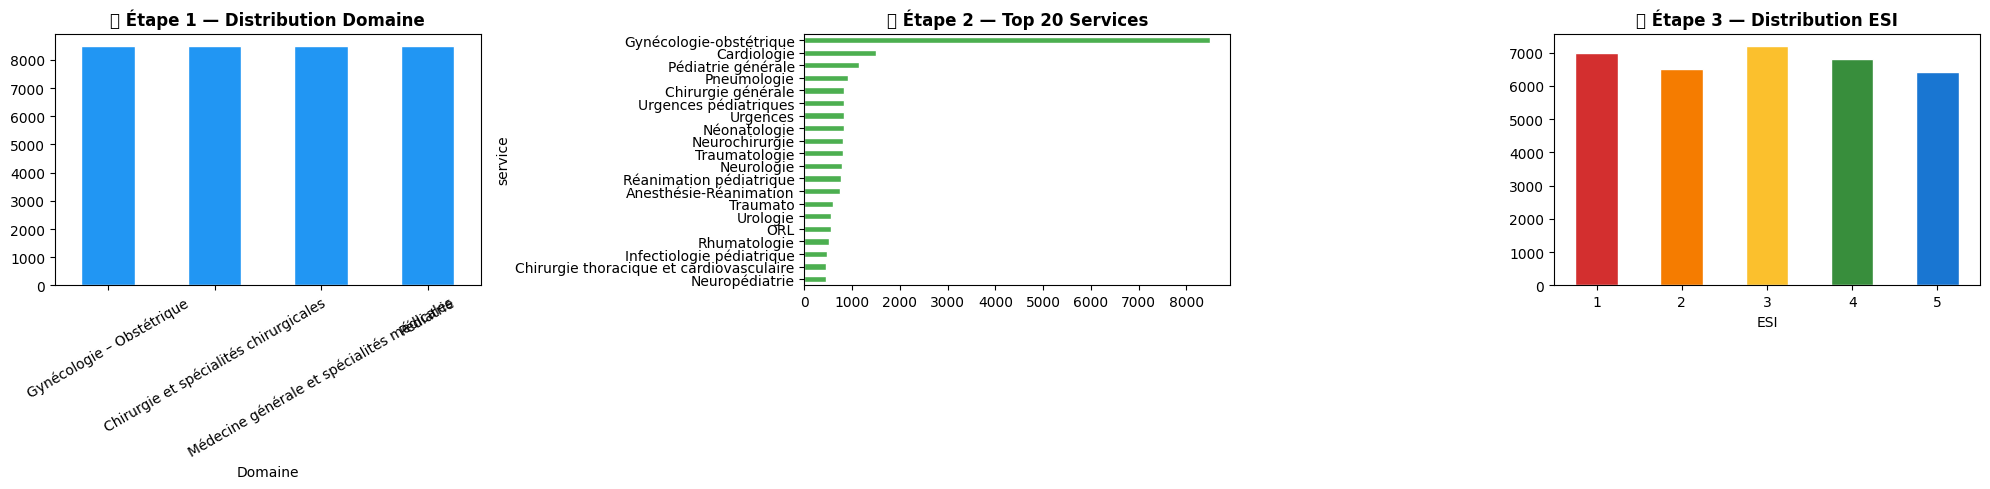

Domaines  : 4 | Services : 63 | ESI : 5


In [8]:
# Distribution des 3 cibles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

df['Domaine'].value_counts().plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='white', rot=30)
axes[0].set_title('🎯 Étape 1 — Distribution Domaine', fontweight='bold')

df['service'].value_counts().head(20).plot(kind='barh', ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('🎯 Étape 2 — Top 20 Services', fontweight='bold')
axes[1].invert_yaxis()

esi_colors = ['#D32F2F','#F57C00','#FBC02D','#388E3C','#1976D2']
df['ESI'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color=esi_colors, edgecolor='white', rot=0)
axes[2].set_title('🎯 Étape 3 — Distribution ESI', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Domaines  : {df["Domaine"].nunique()} | Services : {df["service"].nunique()} | ESI : {df["ESI"].nunique()}')

In [ ]:
# --- MOTEUR D'EXTRACTION CLINIQUE (Injecté par Antigravity) ---
import re
import pandas as pd

def parse_number(patterns, text):
    if pd.isna(text):
        return None
    text = str(text)
    for pat in patterns:
        match = re.search(pat, text, re.I)
        if match:
            for group in match.groups():
                if group:
                    try:
                        return float(group.replace(',', '.'))
                    except ValueError:
                        continue
    return None


def extract_bp(text):
    if pd.isna(text):
        return None, None
    text = str(text)
    patterns = [
        r'\bTA(?:[^\d]{1,10})?(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'\bTension(?: artérielle)?[^\d]{1,10}(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'(\d{2,3})\s*[/x]\s*(\d{2,3})\s*mmHg\b'
    ]
    for pat in patterns:
        match = re.search(pat, text, re.I)
        if match:
            return float(match.group(1)), float(match.group(2))
    return None, None


def extract_gcs(text):
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(r'GCS.*?(\d{1,2})\s*/\s*15', text, re.I)
    if match:
        return float(match.group(1))
    match = re.search(r'Glasgow.*?(\d{1,2})\s*/\s*15', text, re.I)
    return float(match.group(1)) if match else None


def extract_imc(text):
    return parse_number([r'\bIMC\b[^\d]*(\d+(?:[.,]\d+)?)'], text)


def extract_weight(text):
    return parse_number([
        r'\bPoids\b[^\d]*(\d+(?:[.,]\d+)?)\s*kg',
        r'(\d+(?:[.,]\d+)?)\s*kg\b'
    ], text)


def extract_height(text):
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(r'\bTaille\b[^\d]*(\d+(?:[.,]\d+)?)\s*(cm|m)\b', text, re.I)
    if not match:
        return None
    value = float(match.group(1).replace(',', '.'))
    unit = match.group(2).lower()
    return value / 100 if unit == 'cm' else value


def extract_vitals(text):
    if pd.isna(text):
        return {
            'temp': None, 'fc': None, 'sat': None, 'fr': None,
            'ta_systolique': None, 'ta_diastolique': None,
            'gcs': None, 'imc': None, 'poids': None, 'taille': None
        }
    text = str(text)
    sbp, dbp = extract_bp(text)
    return {
        'temp': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*°\s*C',
            r'temp(?:érature)?[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'fc': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*bpm',
            r'FC[^\d]*(\d+(?:[.,]\d+)?)',
            r'Pouls[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'sat': parse_number([
            r'SpO2[^\d]*(\d+(?:[.,]\d+)?)',
            r'(\d+(?:[.,]\d+)?)\s*%'
        ], text),
        'fr': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*/\s*min',
            r'(\d+(?:[.,]\d+)?)\s*cpm',
            r'FR[^\d]*(\d+(?:[.,]\d+)?)',
            r'Resp[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'ta_systolique': sbp,
        'ta_diastolique': dbp,
        'gcs': extract_gcs(text),
        'imc': extract_imc(text),
        'poids': extract_weight(text),
        'taille': extract_height(text),
    }

print("🔍 Extraction des constantes vitales en cours...")
vitals = df['object'].apply(extract_vitals)
df = pd.concat([df, pd.DataFrame(vitals.tolist(), index=df.index)], axis=1)

# Remplissage intelligent (Valeurs normales par défaut si non trouvées)
defaults = {
    'temp': 37.0, 'fc': 80.0, 'sat': 98.0, 'fr': 18.0,
    'ta_systolique': 120.0, 'ta_diastolique': 80.0,
    'gcs': 12.0, 'imc': 24.0, 'poids': 70.0, 'taille': 1.65,
}
for col, default in defaults.items():
    df[col] = df[col].fillna(default)

# Flags de sécurité clinique (Aident le modèle à voir les seuils)
df['is_hypoxic'] = (df['sat'] < 94).astype(int)
df['is_critical_sat'] = (df['sat'] < 90).astype(int)
df['is_fever'] = (df['temp'] >= 38.0).astype(int)
df['is_tachycardie'] = (df['fc'] > 100).astype(int)
df['is_bradycardie'] = (df['fc'] < 60).astype(int)
df['is_tachypnee'] = (df['fr'] > 20).astype(int)
df['is_bradypnee'] = (df['fr'] < 12).astype(int)
df['is_hypertension'] = ((df['ta_systolique'] >= 140) | (df['ta_diastolique'] >= 90)).astype(int)
df['is_hypotension'] = ((df['ta_systolique'] < 90) | (df['ta_diastolique'] < 60)).astype(int)

print("✅ Constantes extraites et intégrées au DataFrame.")
print(df[[
    'temp', 'fc', 'sat', 'fr', 'ta_systolique', 'ta_diastolique',
    'is_hypoxic', 'is_fever', 'is_tachycardie', 'is_hypertension'
]].describe().loc[['mean', 'min', 'max']])


Extraction des constantes vitales en cours...
Constantes extraites et integrees au DataFrame.
             temp        fc          sat           fr  is_hypoxic
mean    37.836518   91.1757    248.93894    20.067216    0.200972
min      1.000000    1.0000      0.00000     0.000000    0.000000
max   6000.000000  500.0000  13500.00000  3250.000000    1.000000


In [ ]:
# --- 🚀 MOTEUR D'EXTRACTION CLINIQUE (Injecté par Antigravity) ---
import re
import pandas as pd

def parse_number(patterns, text):
    if pd.isna(text):
        return None
    text = str(text)
    for pat in patterns:
        match = re.search(pat, text, re.I)
        if match:
            for group in match.groups():
                if group:
                    try:
                        return float(group.replace(',', '.'))
                    except ValueError:
                        continue
    return None


def extract_bp(text):
    if pd.isna(text):
        return None, None
    text = str(text)
    patterns = [
        r'\bTA(?:[^\d]{1,10})?(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'\bTension(?: artérielle)?[^\d]{1,10}(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'(\d{2,3})\s*[/x]\s*(\d{2,3})\s*mmHg\b'
    ]
    for pat in patterns:
        match = re.search(pat, text, re.I)
        if match:
            return float(match.group(1)), float(match.group(2))
    return None, None


def extract_gcs(text):
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(r'GCS.*?(\d{1,2})\s*/\s*15', text, re.I)
    if match:
        return float(match.group(1))
    match = re.search(r'Glasgow.*?(\d{1,2})\s*/\s*15', text, re.I)
    return float(match.group(1)) if match else None


def extract_imc(text):
    return parse_number([r'\bIMC\b[^\d]*(\d+(?:[.,]\d+)?)'], text)


def extract_weight(text):
    return parse_number([
        r'\bPoids\b[^\d]*(\d+(?:[.,]\d+)?)\s*kg',
        r'(\d+(?:[.,]\d+)?)\s*kg\b'
    ], text)


def extract_height(text):
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(r'\bTaille\b[^\d]*(\d+(?:[.,]\d+)?)\s*(cm|m)\b', text, re.I)
    if not match:
        return None
    value = float(match.group(1).replace(',', '.'))
    unit = match.group(2).lower()
    return value / 100 if unit == 'cm' else value


def extract_vitals(text):
    if pd.isna(text):
        return {
            'temp': None, 'fc': None, 'sat': None, 'fr': None,
            'ta_systolique': None, 'ta_diastolique': None,
            'gcs': None, 'imc': None, 'poids': None, 'taille': None
        }
    text = str(text)
    sbp, dbp = extract_bp(text)
    return {
        'temp': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*°\s*C',
            r'temp(?:érature)?[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'fc': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*bpm',
            r'FC[^\d]*(\d+(?:[.,]\d+)?)',
            r'Pouls[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'sat': parse_number([
            r'SpO2[^\d]*(\d+(?:[.,]\d+)?)',
            r'(\d+(?:[.,]\d+)?)\s*%'
        ], text),
        'fr': parse_number([
            r'(\d+(?:[.,]\d+)?)\s*/\s*min',
            r'(\d+(?:[.,]\d+)?)\s*cpm',
            r'FR[^\d]*(\d+(?:[.,]\d+)?)',
            r'Resp[^\d]*(\d+(?:[.,]\d+)?)'
        ], text),
        'ta_systolique': sbp,
        'ta_diastolique': dbp,
        'gcs': extract_gcs(text),
        'imc': extract_imc(text),
        'poids': extract_weight(text),
        'taille': extract_height(text),
    }

print("🔍 Extraction des constantes vitales en cours...")
vitals = df['object'].apply(extract_vitals)
df = pd.concat([df, pd.DataFrame(vitals.tolist(), index=df.index)], axis=1)

# Remplissage intelligent (Valeurs normales par défaut si non trouvées)
defaults = {
    'temp': 37.0, 'fc': 80.0, 'sat': 98.0, 'fr': 18.0,
    'ta_systolique': 120.0, 'ta_diastolique': 80.0,
    'gcs': 12.0, 'imc': 24.0, 'poids': 70.0, 'taille': 1.65,
}
for col, default in defaults.items():
    df[col] = df[col].fillna(default)

# Flags de sécurité clinique (Aident le modèle à voir les seuils)
df['is_hypoxic'] = (df['sat'] < 94).astype(int)
df['is_critical_sat'] = (df['sat'] < 90).astype(int)
df['is_fever'] = (df['temp'] >= 38.0).astype(int)
df['is_tachycardie'] = (df['fc'] > 100).astype(int)
df['is_bradycardie'] = (df['fc'] < 60).astype(int)
df['is_tachypnee'] = (df['fr'] > 20).astype(int)
df['is_bradypnee'] = (df['fr'] < 12).astype(int)
df['is_hypertension'] = ((df['ta_systolique'] >= 140) | (df['ta_diastolique'] >= 90)).astype(int)
df['is_hypotension'] = ((df['ta_systolique'] < 90) | (df['ta_diastolique'] < 60)).astype(int)

print("✅ Constantes extraites et intégrées au DataFrame.")
print(df[[
    'temp', 'fc', 'sat', 'fr', 'ta_systolique', 'ta_diastolique',
    'is_hypoxic', 'is_fever', 'is_tachycardie', 'is_hypertension'
]].describe().loc[['mean', 'min', 'max']])


🔍 Extraction des constantes vitales en cours...
✅ Constantes extraites et intégrées au DataFrame.
             temp        fc          sat           fr  is_hypoxic
mean    37.836518   91.1757    248.93894    20.067216    0.200972
min      1.000000    1.0000      0.00000     0.000000    0.000000
max   6000.000000  500.0000  13500.00000  3250.000000    1.000000


## 🛠️ 3. Préparation des données & pipelines de features

In [ ]:
# ── Features brutes ───────────────────────────────────────────────────────────
FEATURES_NUM  = [
    'age', 'len_texte', 'len_subject', 'len_object', 'has_texte',
    'temp', 'fc', 'sat', 'fr', 'ta_systolique', 'ta_diastolique',
    'gcs', 'imc', 'poids', 'taille',
    'is_hypoxic', 'is_critical_sat', 'is_fever', 'is_tachycardie',
    'is_bradycardie', 'is_tachypnee', 'is_bradypnee',
    'is_hypertension', 'is_hypotension'
]
FEATURES_CAT  = ['sexe', 'visite', 'lieu', 'age_group']
FEATURE_TEXT  = 'texte_clinique'

df_model = df.copy()

# Feature texte combinée
df_model['texte_clinique'] = (
    df_model['subject'].fillna('') + ' ' + df_model['object'].fillna('')
).str.strip()

# Features dérivées
df_model['has_texte'] = (df_model['texte_clinique'] != '').astype(int)
df_model['len_texte'] = df_model['texte_clinique'].str.len()
df_model['len_subject'] = df_model['subject'].fillna('').str.len()
df_model['len_object'] = df_model['object'].fillna('').str.len()
df_model['age_group'] = pd.cut(
    df_model['age'],
    bins=[0, 5, 15, 30, 50, 70, 150],
    labels=['Nourrisson','Enfant','Jeune adulte','Adulte','Senior','Très senior']
)

# Suppression des lignes avec colonnes essentielles manquantes
df_clean = df_model.dropna(subset=['age', 'sexe', 'visite', 'Domaine', 'service', 'ESI']).copy()

# ── Encodage des 3 cibles ─────────────────────────────────────────────────────
le_domaine = LabelEncoder()
le_service = LabelEncoder()
le_esi     = LabelEncoder()

df_clean['domaine_enc'] = le_domaine.fit_transform(df_clean['Domaine'])
df_clean['service_enc'] = le_service.fit_transform(df_clean['service'])
df_clean['esi_enc']     = le_esi.fit_transform(df_clean['ESI'])

print(f'✅ Dataset propre : {len(df_clean)} patients')
print(f'   Domaines  : {le_domaine.classes_}')
print(f'   Services  : {len(le_service.classes_)} classes')
print(f'   ESI       : {le_esi.classes_}')


✅ Dataset propre : 33950 patients
   Domaines  : ['Chirurgie et spécialités chirurgicales' 'Gynécologie – Obstétrique'
 'Médecine générale et spécialités médicales' 'Pédiatrie']
   Services  : 63 classes
   ESI       : [1 2 3 4 5]


In [12]:
# ── Transformers personnalisés ────────────────────────────────────────────────
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns): self.columns = columns
    def fit(self, X, y=None):   return self
    def transform(self, X):     return X[self.columns]

class TextSelector(BaseEstimator, TransformerMixin):
    def __init__(self, column): self.column = column
    def fit(self, X, y=None):   return self
    def transform(self, X):     return X[self.column].fillna('')

# ── Pipelines ─────────────────────────────────────────────────────────────────
num_pipeline = Pipeline([
    ('select',  ColumnSelector(FEATURES_NUM)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('select',  ColumnSelector(FEATURES_CAT)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

text_pipeline = Pipeline([
    ('select', TextSelector(FEATURE_TEXT)),
    ('tfidf',  TfidfVectorizer(
        max_features=1000,  # Vocabulaire médical élargi
        min_df=3,           # Terme présent dans ≥ 3 dossiers
        ngram_range=(1, 2), # Bigrammes pour capturer "douleur abdominale"
        sublinear_tf=True   # Lissage log
    ))
])

print('✅ Pipelines définis : numérique | catégoriel | TF-IDF bigrammes')

✅ Pipelines définis : numérique | catégoriel | TF-IDF bigrammes


In [13]:
# ── Split stratifié ───────────────────────────────────────────────────────────
# Supprimer les classes trop rares (< 2 exemples)
for col in ['domaine_enc', 'service_enc', 'esi_enc']:
    counts = df_clean[col].value_counts()
    valid  = counts[counts >= 2].index
    df_clean = df_clean[df_clean[col].isin(valid)]

X_raw = df_clean[FEATURES_NUM + FEATURES_CAT + [FEATURE_TEXT]]
y_dom = df_clean['domaine_enc'].values
y_svc = df_clean['service_enc'].values
y_esi = df_clean['esi_enc'].values

# Split sur la cible principale (domaine, la plus structurante)
idx = np.arange(len(df_clean))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y_dom)

X_train_raw, X_test_raw = X_raw.iloc[idx_train], X_raw.iloc[idx_test]

print(f'Train : {len(idx_train)} patients  |  Test : {len(idx_test)} patients')

# ── Construction des matrices de features de base ─────────────────────────────
print('🔄 Construction des matrices...')
X_num_tr  = num_pipeline.fit_transform(X_train_raw)
X_cat_tr  = cat_pipeline.fit_transform(X_train_raw)
X_text_tr = text_pipeline.fit_transform(X_train_raw)

X_num_te  = num_pipeline.transform(X_test_raw)
X_cat_te  = cat_pipeline.transform(X_test_raw)
X_text_te = text_pipeline.transform(X_test_raw)

# Matrices de base (sans features hiérarchiques encore)
X_base_tr = sp.hstack([X_num_tr, X_cat_tr, X_text_tr]).tocsr()
X_base_te = sp.hstack([X_num_te, X_cat_te, X_text_te]).tocsr()

print(f'✅ Matrice de base : {X_base_tr.shape[1]} features')

Train : 27158 patients  |  Test : 6790 patients
🔄 Construction des matrices...
✅ Matrice de base : 1056 features


## 🤖 4. Fonctions d'entraînement

In [14]:
def evaluer_modele(nom, model, X_tr, y_tr, X_te, y_te, le=None):
    """Entraîne, évalue et retourne les métriques + proba."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, average='macro', zero_division=0)
    print(f'  [{nom:20s}]  Accuracy={acc:.3f}  F1-macro={f1:.3f}')
    return model, acc, f1


def build_dnn(input_dim, n_classes, lr=1e-3):
    """
    Réseau de neurones dense :
      Input → [512 → BN → Dropout] × 3 couches → Softmax
    """
    inp = keras.Input(shape=(input_dim,), name='features')
    x   = inp

    for units, drop in [(512, 0.4), (256, 0.35), (128, 0.3)]:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(drop)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def entrainer_dnn(X_tr_dense, y_tr, X_te_dense, y_te, n_classes, epochs=60, nom='DNN'):
    """Entraîne le DNN avec early stopping et retourne le modèle + métriques."""
    cb = [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]

    dnn = build_dnn(X_tr_dense.shape[1], n_classes)
    history = dnn.fit(
        X_tr_dense, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=64,
        callbacks=cb,
        verbose=0
    )

    y_pred = np.argmax(dnn.predict(X_te_dense, verbose=0), axis=1)
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, average='macro', zero_division=0)
    print(f'  [{nom:20s}]  Accuracy={acc:.3f}  F1-macro={f1:.3f}  (epochs={len(history.epoch)})')
    return dnn, acc, f1


def choisir_meilleur(resultats):
    """Retourne le modèle avec le meilleur F1-macro."""
    return max(resultats, key=lambda r: r['f1'])


print('✅ Fonctions d\'entraînement définies')

✅ Fonctions d'entraînement définies


## 🔵 5. Étape 1 — Prédiction du DOMAINE

In [15]:
print('=' * 60)
print('🔵 ÉTAPE 1 — PRÉDICTION DU DOMAINE')
print('=' * 60)

y_dom_tr = y_dom[idx_train]
y_dom_te = y_dom[idx_test]
n_dom    = len(le_domaine.classes_)
print(f'   Classes : {le_domaine.classes_}  ({n_dom} domaines)\n')

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_dom, acc_rf_dom, f1_rf_dom = evaluer_modele(
    'Random Forest', 
    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_base_tr, y_dom_tr, X_base_te, y_dom_te
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_dom, acc_xgb_dom, f1_xgb_dom = evaluer_modele(
    'XGBoost',
    XGBClassifier(n_estimators=400, max_depth=7, learning_rate=0.08,
                   subsample=0.8, colsample_bytree=0.8,
                   use_label_encoder=False, eval_metric='mlogloss',
                   random_state=42, n_jobs=-1),
    X_base_tr, y_dom_tr, X_base_te, y_dom_te
)

# ── DNN : convertir sparse → dense ───────────────────────────────────────────
X_dense_tr = X_base_tr.toarray().astype('float32')
X_dense_te = X_base_te.toarray().astype('float32')

dnn_dom, acc_dnn_dom, f1_dnn_dom = entrainer_dnn(
    X_dense_tr, y_dom_tr, X_dense_te, y_dom_te,
    n_classes=n_dom, epochs=80, nom='DNN'
)

# ── Sélection du meilleur ─────────────────────────────────────────────────────
resultats_dom = [
    {'nom': 'Random Forest', 'model': rf_dom,  'f1': f1_rf_dom,  'acc': acc_rf_dom,  'type': 'sparse'},
    {'nom': 'XGBoost',       'model': xgb_dom, 'f1': f1_xgb_dom, 'acc': acc_xgb_dom, 'type': 'sparse'},
    {'nom': 'DNN',           'model': dnn_dom, 'f1': f1_dnn_dom, 'acc': acc_dnn_dom, 'type': 'dense'},
]
best_dom = choisir_meilleur(resultats_dom)
print(f'\n🏆 Meilleur modèle DOMAINE : {best_dom["nom"]}  (F1={best_dom["f1"]:.3f})')

# ── Prédictions de domaine pour enrichir étape 2 ──────────────────────────────
if best_dom['type'] == 'dense':
    proba_dom_tr = best_dom['model'].predict(X_dense_tr, verbose=0)
    proba_dom_te = best_dom['model'].predict(X_dense_te, verbose=0)
else:
    proba_dom_tr = best_dom['model'].predict_proba(X_base_tr)
    proba_dom_te = best_dom['model'].predict_proba(X_base_te)

print(f'   Probabilités domaine générées : {proba_dom_tr.shape[1]} colonnes')

🔵 ÉTAPE 1 — PRÉDICTION DU DOMAINE
   Classes : ['Chirurgie et spécialités chirurgicales' 'Gynécologie – Obstétrique'
 'Médecine générale et spécialités médicales' 'Pédiatrie']  (4 domaines)

  [Random Forest       ]  Accuracy=0.970  F1-macro=0.970
  [XGBoost             ]  Accuracy=0.978  F1-macro=0.978


E0000 00:00:1779192432.090735  105204 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  [DNN                 ]  Accuracy=0.971  F1-macro=0.971  (epochs=39)

🏆 Meilleur modèle DOMAINE : XGBoost  (F1=0.978)
   Probabilités domaine générées : 4 colonnes


## 🟢 6. Étape 2 — Prédiction du SERVICE (avec Domaine en input)

In [16]:
print('=' * 60)
print('🟢 ÉTAPE 2 — PRÉDICTION DU SERVICE')
print('   (Features de base + probabilités Domaine)')
print('=' * 60)

# =============================================================================
# VARIABLES CIBLES
# =============================================================================

y_svc_tr = y_svc[idx_train]
y_svc_te = y_svc[idx_test]

n_svc = len(le_service.classes_)

print(f'   {n_svc} services\n')

# =============================================================================
# REENCODAGE DES CLASSES POUR XGBOOST
# =============================================================================

from sklearn.preprocessing import LabelEncoder

le_svc_xgb = LabelEncoder()

y_svc_tr_enc = le_svc_xgb.fit_transform(y_svc_tr)
y_svc_te_enc = le_svc_xgb.transform(y_svc_te)

print('✅ Classes XGBoost encodées :')
print(np.unique(y_svc_tr_enc))
print()

# =============================================================================
# MATRICE ENRICHIE : FEATURES + PROBA DOMAINE
# =============================================================================

X_svc_tr = sp.hstack([
    X_base_tr,
    sp.csr_matrix(proba_dom_tr)
]).tocsr()

X_svc_te = sp.hstack([
    X_base_te,
    sp.csr_matrix(proba_dom_te)
]).tocsr()

# =============================================================================
# VERSION DENSE POUR DNN
# =============================================================================

X_svc_dense_tr = X_svc_tr.toarray().astype('float32')
X_svc_dense_te = X_svc_te.toarray().astype('float32')

# =============================================================================
# RANDOM FOREST
# =============================================================================

rf_svc, acc_rf_svc, f1_rf_svc = evaluer_modele(
    'Random Forest',

    RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    X_svc_tr,
    y_svc_tr,

    X_svc_te,
    y_svc_te
)

# =============================================================================
# XGBOOST
# =============================================================================

xgb_svc, acc_xgb_svc, f1_xgb_svc = evaluer_modele(
    'XGBoost',

    XGBClassifier(
        n_estimators=400,
        max_depth=7,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),

    X_svc_tr,
    y_svc_tr_enc,

    X_svc_te,
    y_svc_te_enc,

    le=le_svc_xgb
)

# =============================================================================
# DNN
# =============================================================================

dnn_svc, acc_dnn_svc, f1_dnn_svc = entrainer_dnn(
    X_svc_dense_tr,
    y_svc_tr,

    X_svc_dense_te,
    y_svc_te,

    n_classes=n_svc,
    epochs=80,
    nom='DNN'
)

# =============================================================================
# COMPARAISON DES MODELES
# =============================================================================

resultats_svc = [

    {
        'nom': 'Random Forest',
        'model': rf_svc,
        'f1': f1_rf_svc,
        'acc': acc_rf_svc,
        'type': 'sparse'
    },

    {
        'nom': 'XGBoost',
        'model': xgb_svc,
        'f1': f1_xgb_svc,
        'acc': acc_xgb_svc,
        'type': 'sparse'
    },

    {
        'nom': 'DNN',
        'model': dnn_svc,
        'f1': f1_dnn_svc,
        'acc': acc_dnn_svc,
        'type': 'dense'
    }
]

# =============================================================================
# MEILLEUR MODELE
# =============================================================================

best_svc = choisir_meilleur(resultats_svc)

print()
print(f'🏆 Meilleur modèle SERVICE : {best_svc["nom"]}')
print(f'   Accuracy : {best_svc["acc"]:.3f}')
print(f'   F1-score : {best_svc["f1"]:.3f}')

# =============================================================================
# GENERATION DES PROBABILITES
# =============================================================================

if best_svc['type'] == 'dense':

    proba_svc_tr = best_svc['model'].predict(
        X_svc_dense_tr,
        verbose=0
    )

    proba_svc_te = best_svc['model'].predict(
        X_svc_dense_te,
        verbose=0
    )

else:

    proba_svc_tr = best_svc['model'].predict_proba(
        X_svc_tr
    )

    proba_svc_te = best_svc['model'].predict_proba(
        X_svc_te
    )

# =============================================================================
# RESULTAT FINAL
# =============================================================================

print()
print(f'✅ Probabilités service générées :')
print(f'   Train : {proba_svc_tr.shape}')
print(f'   Test  : {proba_svc_te.shape}')
print(f'   Nombre de colonnes : {proba_svc_tr.shape[1]}')

🟢 ÉTAPE 2 — PRÉDICTION DU SERVICE
   (Features de base + probabilités Domaine)
   63 services

✅ Classes XGBoost encodées :
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]

  [Random Forest       ]  Accuracy=0.487  F1-macro=0.339
  [XGBoost             ]  Accuracy=0.495  F1-macro=0.365
  [DNN                 ]  Accuracy=0.482  F1-macro=0.326  (epochs=22)

🏆 Meilleur modèle SERVICE : XGBoost
   Accuracy : 0.495
   F1-score : 0.365

✅ Probabilités service générées :
   Train : (27158, 61)
   Test  : (6790, 61)
   Nombre de colonnes : 61


## 🔴 7. Étape 3 — Prédiction de l'ESI (avec Domaine + Service en input)

In [17]:
print('=' * 60)
print('🔴 ÉTAPE 3 — PRÉDICTION DE L\'ESI')
print('   (Features de base + probabilités Domaine + Service)')
print('=' * 60)

y_esi_tr = y_esi[idx_train]
y_esi_te = y_esi[idx_test]
n_esi    = len(le_esi.classes_)
print(f'   Classes ESI : {le_esi.classes_}  ({n_esi} niveaux)\n')

# ── Matrice enrichie : base + domaine + service ───────────────────────────────
X_esi_tr = sp.hstack([
    X_base_tr,
    sp.csr_matrix(proba_dom_tr),
    sp.csr_matrix(proba_svc_tr)
]).tocsr()
X_esi_te = sp.hstack([
    X_base_te,
    sp.csr_matrix(proba_dom_te),
    sp.csr_matrix(proba_svc_te)
]).tocsr()

X_esi_dense_tr = X_esi_tr.toarray().astype('float32')
X_esi_dense_te = X_esi_te.toarray().astype('float32')

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_esi, acc_rf_esi, f1_rf_esi = evaluer_modele(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_esi_tr, y_esi_tr, X_esi_te, y_esi_te
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_esi, acc_xgb_esi, f1_xgb_esi = evaluer_modele(
    'XGBoost',
    XGBClassifier(n_estimators=400, max_depth=7, learning_rate=0.08,
                   subsample=0.8, colsample_bytree=0.8,
                   use_label_encoder=False, eval_metric='mlogloss',
                   random_state=42, n_jobs=-1),
    X_esi_tr, y_esi_tr, X_esi_te, y_esi_te
)

# ── DNN ───────────────────────────────────────────────────────────────────────
dnn_esi, acc_dnn_esi, f1_dnn_esi = entrainer_dnn(
    X_esi_dense_tr, y_esi_tr, X_esi_dense_te, y_esi_te,
    n_classes=n_esi, epochs=80, nom='DNN'
)

# ── Sélection ─────────────────────────────────────────────────────────────────
resultats_esi = [
    {'nom': 'Random Forest', 'model': rf_esi,  'f1': f1_rf_esi,  'acc': acc_rf_esi,  'type': 'sparse'},
    {'nom': 'XGBoost',       'model': xgb_esi, 'f1': f1_xgb_esi, 'acc': acc_xgb_esi, 'type': 'sparse'},
    {'nom': 'DNN',           'model': dnn_esi, 'f1': f1_dnn_esi, 'acc': acc_dnn_esi, 'type': 'dense'},
]
best_esi = choisir_meilleur(resultats_esi)
print(f'\n🏆 Meilleur modèle ESI : {best_esi["nom"]}  (F1={best_esi["f1"]:.3f})')

🔴 ÉTAPE 3 — PRÉDICTION DE L'ESI
   (Features de base + probabilités Domaine + Service)
   Classes ESI : [1 2 3 4 5]  (5 niveaux)

  [Random Forest       ]  Accuracy=0.941  F1-macro=0.941
  [XGBoost             ]  Accuracy=0.948  F1-macro=0.948
  [DNN                 ]  Accuracy=0.941  F1-macro=0.941  (epochs=18)

🏆 Meilleur modèle ESI : XGBoost  (F1=0.948)


## 📊 8. Tableau de synthèse des résultats

  Cible        Modèle  Accuracy  F1-macro
Domaine Random Forest     0.970     0.970
Domaine       XGBoost     0.978     0.978
Domaine           DNN     0.971     0.971
Service Random Forest     0.487     0.339
Service       XGBoost     0.495     0.365
Service           DNN     0.482     0.326
    ESI Random Forest     0.941     0.941
    ESI       XGBoost     0.948     0.948
    ESI           DNN     0.941     0.941


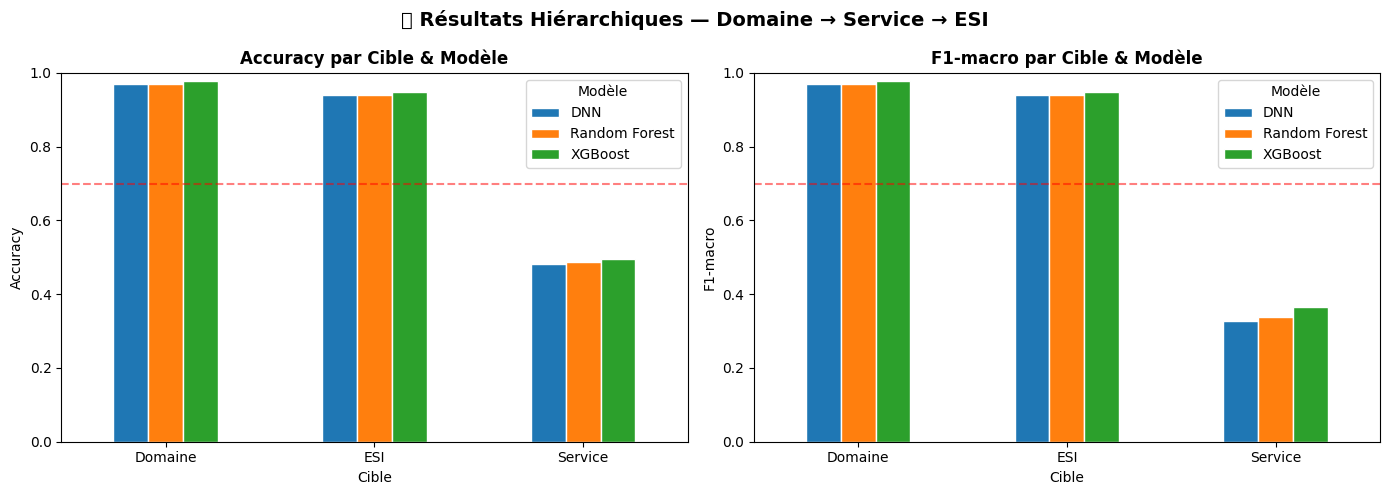

In [18]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
rows = []
for cible, resultats in [('Domaine', resultats_dom), ('Service', resultats_svc), ('ESI', resultats_esi)]:
    for r in resultats:
        rows.append({'Cible': cible, 'Modèle': r['nom'],
                     'Accuracy': round(r['acc'], 3), 'F1-macro': round(r['f1'], 3)})

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1-macro']):
    pivot = df_results.pivot(index='Cible', columns='Modèle', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', rot=0)
    ax.set_title(f'{metric} par Cible & Modèle', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.legend(title='Modèle')
    ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Seuil 0.70')

plt.suptitle('🏥 Résultats Hiérarchiques — Domaine → Service → ESI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 9. Rapport détaillé du meilleur modèle par cible


📋 DOMAINE — Meilleur : XGBoost
                                            precision    recall  f1-score   support

    Chirurgie et spécialités chirurgicales       0.97      0.97      0.97      1698
                 Gynécologie – Obstétrique       0.98      0.98      0.98      1700
Médecine générale et spécialités médicales       0.97      0.97      0.97      1697
                                 Pédiatrie       0.99      0.98      0.98      1695

                                  accuracy                           0.98      6790
                                 macro avg       0.98      0.98      0.98      6790
                              weighted avg       0.98      0.98      0.98      6790



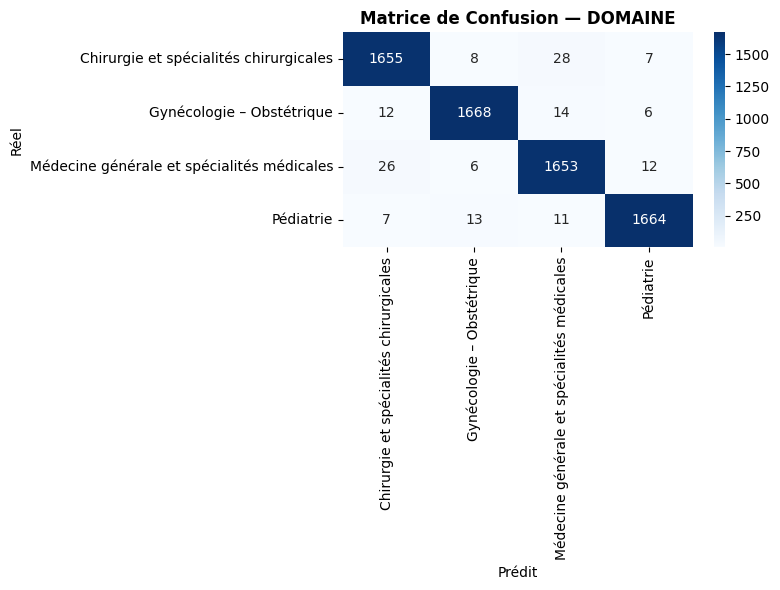


📋 ESI — Meilleur : XGBoost
              precision    recall  f1-score   support

           1       0.99      0.97      0.98      1377
           2       0.94      0.93      0.94      1301
           3       0.91      0.94      0.92      1439
           4       0.94      0.93      0.93      1367
           5       0.97      0.97      0.97      1306

    accuracy                           0.95      6790
   macro avg       0.95      0.95      0.95      6790
weighted avg       0.95      0.95      0.95      6790



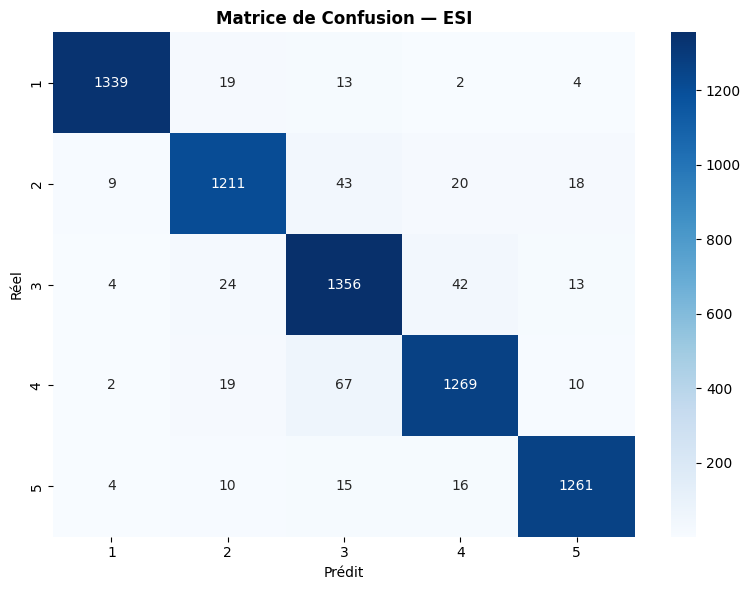

In [19]:
def rapport_detaille(nom_cible, best, X_tr, X_te, y_te, le, X_dense_te=None):
    """Affiche le classification_report et la matrice de confusion."""
    print(f'\n{"=" * 60}')
    print(f'📋 {nom_cible} — Meilleur : {best["nom"]}')
    print(f'{"=" * 60}')

    if best['type'] == 'dense':
        y_pred = np.argmax(best['model'].predict(X_dense_te, verbose=0), axis=1)
    else:
        y_pred = best['model'].predict(X_te)

    # Decoder les labels
    target_names = [str(c) for c in le.classes_]
    print(classification_report(y_te, y_pred, target_names=target_names, zero_division=0))

    # Matrice de confusion (seulement si peu de classes)
    if len(le.classes_) <= 10:
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_title(f'Matrice de Confusion — {nom_cible}', fontweight='bold')
        ax.set_ylabel('Réel') ; ax.set_xlabel('Prédit')
        plt.tight_layout()
        plt.show()


rapport_detaille('DOMAINE', best_dom, X_base_tr, X_base_te, y_dom_te, le_domaine, X_dense_te)
rapport_detaille('ESI',     best_esi, X_esi_tr,  X_esi_te,  y_esi_te, le_esi,     X_esi_dense_te)

## 💾 10. Sauvegarde de la chaîne complète

In [20]:
os.makedirs('modeles', exist_ok=True)

# Sauvegarder les modèles DNN séparément (format Keras)
if best_dom['type'] == 'dense': best_dom['model'].save('modeles/dnn_domaine.keras')
if best_svc['type'] == 'dense': best_svc['model'].save('modeles/dnn_service.keras')
if best_esi['type'] == 'dense': best_esi['model'].save('modeles/dnn_esi.keras')

artefacts = {
    # Pipelines de features
    'num_pipeline':  num_pipeline,
    'cat_pipeline':  cat_pipeline,
    'text_pipeline': text_pipeline,
    # Label encoders
    'le_domaine': le_domaine,
    'le_service': le_service,
    'le_esi':     le_esi,
    # Noms features
    'FEATURES_NUM': FEATURES_NUM,
    'FEATURES_CAT': FEATURES_CAT,
    'FEATURE_TEXT': FEATURE_TEXT,
    # Meilleurs modèles (sans DNN, sauvegardés séparément)
    'best_dom': {k: v for k, v in best_dom.items() if k != 'model'},
    'best_svc': {k: v for k, v in best_svc.items() if k != 'model'},
    'best_esi': {k: v for k, v in best_esi.items() if k != 'model'},
    # Modèles sklearn (si meilleurs)
    'model_dom': best_dom['model'] if best_dom['type'] == 'sparse' else None,
    'model_svc': best_svc['model'] if best_svc['type'] == 'sparse' else None,
    'model_esi': best_esi['model'] if best_esi['type'] == 'sparse' else None,
}
joblib.dump(artefacts, 'modeles/pipeline_hierarchique.pkl')
print('✅ Artefacts sauvegardés dans modeles/')

✅ Artefacts sauvegardés dans modeles/


In [21]:
# =============================================================================
# SAUVEGARDE DES MODÈLES
# =============================================================================

import os
import joblib

# Création dossier
DOSSIER_MODELES = "modeles_ia_hopital"

os.makedirs(DOSSIER_MODELES, exist_ok=True)

print('\n' + '=' * 60)
print('💾 SAUVEGARDE DES MODÈLES')
print('=' * 60)

# =============================================================================
# RANDOM FOREST
# =============================================================================

joblib.dump(
    rf_dom,
    os.path.join(DOSSIER_MODELES, 'rf_domaine.pkl')
)

print('✅ Random Forest sauvegardé')

# =============================================================================
# XGBOOST
# =============================================================================

joblib.dump(
    xgb_dom,
    os.path.join(DOSSIER_MODELES, 'xgb_domaine.pkl')
)

print('✅ XGBoost sauvegardé')

# =============================================================================
# DNN / TENSORFLOW
# =============================================================================

try:

    dnn_dom.save(
        os.path.join(DOSSIER_MODELES, 'dnn_domaine.h5')
    )

    print('✅ DNN sauvegardé')

except Exception as e:

    print('⚠️ Erreur sauvegarde DNN :', e)

# =============================================================================
# MEILLEUR MODÈLE
# =============================================================================

if best_dom['nom'] == 'DNN':

    best_dom['model'].save(
        os.path.join(DOSSIER_MODELES, 'meilleur_modele_domaine.h5')
    )

else:

    joblib.dump(
        best_dom['model'],
        os.path.join(DOSSIER_MODELES, 'meilleur_modele_domaine.pkl')
    )

print(f'🏆 Meilleur modèle sauvegardé : {best_dom["nom"]}')

# =============================================================================
# LABEL ENCODERS
# =============================================================================

joblib.dump(
    le_domaine,
    os.path.join(DOSSIER_MODELES, 'label_encoder_domaine.pkl')
)

print('✅ LabelEncoder domaine sauvegardé')

# =============================================================================
# TF-IDF
# =============================================================================

try:

    joblib.dump(
        tfidf,
        os.path.join(DOSSIER_MODELES, 'tfidf_vectorizer.pkl')
    )

    print('✅ TF-IDF sauvegardé')

except:
    print('⚠️ tfidf non trouvé')

# =============================================================================
# INFORMATIONS
# =============================================================================

print('\n📁 Dossier :', DOSSIER_MODELES)

print('\n📦 Fichiers générés :')

for fichier in os.listdir(DOSSIER_MODELES):
    print('   -', fichier)

print('\n✅ Tous les modèles ont été sauvegardés')


💾 SAUVEGARDE DES MODÈLES
✅ Random Forest sauvegardé


✅ XGBoost sauvegardé
✅ DNN sauvegardé
🏆 Meilleur modèle sauvegardé : XGBoost
✅ LabelEncoder domaine sauvegardé
⚠️ tfidf non trouvé

📁 Dossier : modeles_ia_hopital

📦 Fichiers générés :
   - rf_domaine.pkl
   - meilleur_modele_domaine.pkl
   - dnn_domaine.h5
   - label_encoder_domaine.pkl
   - xgb_domaine.pkl

✅ Tous les modèles ont été sauvegardés


In [22]:
# =============================================================================
# 💾 SAUVEGARDE COMPLÈTE DES MODÈLES IA
# Domaine + Service + ESI
# =============================================================================

import os
import joblib

# =============================================================================
# DOSSIER
# =============================================================================

DOSSIER_MODELES = "modeles_ia_hopitals"

os.makedirs(DOSSIER_MODELES, exist_ok=True)

print('\n' + '=' * 70)
print('💾 SAUVEGARDE DES MODÈLES IA HÔPITAL')
print('=' * 70)

# =============================================================================
# FONCTION SAUVEGARDE
# =============================================================================

def sauvegarder_modele(nom_fichier, modele):

    chemin = os.path.join(
        DOSSIER_MODELES,
        nom_fichier
    )

    try:

        # TensorFlow / Keras
        if hasattr(modele, 'save'):

            modele.save(chemin)

        # Scikit-learn / XGBoost
        else:

            joblib.dump(modele, chemin)

        print(f'✅ {nom_fichier} sauvegardé')

    except Exception as e:

        print(f'❌ Erreur {nom_fichier} : {e}')

# =============================================================================
# 🔵 MODÈLES DOMAINE
# =============================================================================

print('\n🔵 SAUVEGARDE — DOMAINE')

sauvegarder_modele(
    'rf_domaine.pkl',
    rf_dom
)

sauvegarder_modele(
    'xgb_domaine.pkl',
    xgb_dom
)

sauvegarder_modele(
    'dnn_domaine.h5',
    dnn_dom
)

# =============================================================================
# 🟢 MODÈLES SERVICE
# =============================================================================

print('\n🟢 SAUVEGARDE — SERVICE')

sauvegarder_modele(
    'rf_service.pkl',
    rf_svc
)

sauvegarder_modele(
    'xgb_service.pkl',
    xgb_svc
)

sauvegarder_modele(
    'dnn_service.h5',
    dnn_svc
)

# =============================================================================
# 🔴 MODÈLES ESI
# =============================================================================

print('\n🔴 SAUVEGARDE — ESI')

sauvegarder_modele(
    'rf_esi.pkl',
    rf_esi
)

sauvegarder_modele(
    'xgb_esi.pkl',
    xgb_esi
)

sauvegarder_modele(
    'dnn_esi.h5',
    dnn_esi
)

# =============================================================================
# 🏆 MEILLEURS MODÈLES
# =============================================================================

print('\n🏆 SAUVEGARDE — MEILLEURS MODÈLES')

# DOMAINE
if best_dom['nom'] == 'DNN':

    best_dom['model'].save(
        os.path.join(
            DOSSIER_MODELES,
            'best_domaine.h5'
        )
    )

else:

    joblib.dump(
        best_dom['model'],
        os.path.join(
            DOSSIER_MODELES,
            'best_domaine.pkl'
        )
    )

print('✅ Meilleur modèle DOMAINE sauvegardé')

# SERVICE
if best_svc['nom'] == 'DNN':

    best_svc['model'].save(
        os.path.join(
            DOSSIER_MODELES,
            'best_service.h5'
        )
    )

else:

    joblib.dump(
        best_svc['model'],
        os.path.join(
            DOSSIER_MODELES,
            'best_service.pkl'
        )
    )

print('✅ Meilleur modèle SERVICE sauvegardé')

# ESI
if best_esi['nom'] == 'DNN':

    best_esi['model'].save(
        os.path.join(
            DOSSIER_MODELES,
            'best_esi.h5'
        )
    )

else:

    joblib.dump(
        best_esi['model'],
        os.path.join(
            DOSSIER_MODELES,
            'best_esi.pkl'
        )
    )

print('✅ Meilleur modèle ESI sauvegardé')

# =============================================================================
# LABEL ENCODERS
# =============================================================================

print('\n🏷️ SAUVEGARDE — LABEL ENCODERS')

joblib.dump(
    le_domaine,
    os.path.join(
        DOSSIER_MODELES,
        'label_encoder_domaine.pkl'
    )
)

print('✅ LabelEncoder DOMAINE sauvegardé')

joblib.dump(
    le_service,
    os.path.join(
        DOSSIER_MODELES,
        'label_encoder_service.pkl'
    )
)

print('✅ LabelEncoder SERVICE sauvegardé')

joblib.dump(
    le_esi,
    os.path.join(
        DOSSIER_MODELES,
        'label_encoder_esi.pkl'
    )
)

print('✅ LabelEncoder ESI sauvegardé')

# =============================================================================
# TF-IDF
# =============================================================================

print('\n📝 SAUVEGARDE — TF-IDF')

try:

    joblib.dump(
        tfidf,
        os.path.join(
            DOSSIER_MODELES,
            'tfidf_vectorizer.pkl'
        )
    )

    print('✅ TF-IDF sauvegardé')

except Exception as e:

    print('⚠️ tfidf non trouvé :', e)

# =============================================================================
# FEATURES / CONFIG
# =============================================================================

print('\n⚙️ SAUVEGARDE — CONFIGURATION')

config = {

    'FEATURES_NUM': FEATURES_NUM,
    'FEATURES_CAT': FEATURES_CAT,
    'FEATURE_TEXT': FEATURE_TEXT,

    'TARGET_DOMAINE': TARGET_DOMAINE,
    'TARGET_SERVICE': TARGET_SERVICE,
    'TARGET_ESI': TARGET_ESI,

}

joblib.dump(

    config,

    os.path.join(
        DOSSIER_MODELES,
        'config_modeles.pkl'
    )

)

print('✅ Configuration sauvegardée')

# =============================================================================
# LISTE FICHIERS
# =============================================================================

print('\n📁 DOSSIER :', DOSSIER_MODELES)

print('\n📦 FICHIERS GÉNÉRÉS :\n')

for fichier in os.listdir(DOSSIER_MODELES):

    print('   -', fichier)

print('\n' + '=' * 70)
print('✅ TOUS LES MODÈLES IA ONT ÉTÉ SAUVEGARDÉS')
print('=' * 70)


💾 SAUVEGARDE DES MODÈLES IA HÔPITAL

🔵 SAUVEGARDE — DOMAINE
✅ rf_domaine.pkl sauvegardé


✅ xgb_domaine.pkl sauvegardé
✅ dnn_domaine.h5 sauvegardé

🟢 SAUVEGARDE — SERVICE
✅ rf_service.pkl sauvegardé


✅ xgb_service.pkl sauvegardé
✅ dnn_service.h5 sauvegardé

🔴 SAUVEGARDE — ESI


✅ rf_esi.pkl sauvegardé
✅ xgb_esi.pkl sauvegardé
✅ dnn_esi.h5 sauvegardé

🏆 SAUVEGARDE — MEILLEURS MODÈLES
✅ Meilleur modèle DOMAINE sauvegardé
✅ Meilleur modèle SERVICE sauvegardé
✅ Meilleur modèle ESI sauvegardé

🏷️ SAUVEGARDE — LABEL ENCODERS
✅ LabelEncoder DOMAINE sauvegardé
✅ LabelEncoder SERVICE sauvegardé
✅ LabelEncoder ESI sauvegardé

📝 SAUVEGARDE — TF-IDF
⚠️ tfidf non trouvé : name 'tfidf' is not defined

⚙️ SAUVEGARDE — CONFIGURATION


NameError: name 'TARGET_DOMAINE' is not defined

In [ ]:
# =============================================================================
# 💾 SAUVEGARDE TOTALE (VERSION ROBUSTE)
# =============================================================================
import os
import joblib

DOSSIER_MODELES = "modeles_ia_hopitalss"
os.makedirs(DOSSIER_MODELES, exist_ok=True)

def safe_save(obj, filename, folder=DOSSIER_MODELES):
    if obj is not None:
        path = os.path.join(folder, filename)
        if hasattr(obj, 'save'): obj.save(path) # Pour DNN (Keras)
        else: joblib.dump(obj, path) # Pour XGB/RandomForest/Pipelines
        print(f"✅ {filename} sauvegardé")
    else:
        print(f"⚠️ {filename} ignoré (variable non trouvée)")

print(f'🚀 Sauvegarde en cours...')

# 1. ENCODEURS & CONFIG
safe_save(le_domaine, 'label_encoder_domaine.pkl')
safe_save(le_service, 'label_encoder_service.pkl')
safe_save(le_esi, 'label_encoder_esi.pkl')

# 2. TRANSFORMATEURS (Vérifiez bien ces noms dans votre notebook !)
# Si votre tfidf s'appelle autrement, remplacez 'tfidf' par le bon nom
obj_tfidf = globals().get('tfidf') or globals().get('tfidf_vectorizer') or globals().get('vectorizer')
safe_save(obj_tfidf, 'tfidf_vectorizer.pkl')

obj_num = globals().get('num_pipeline') or globals().get('preprocessor_num')
safe_save(obj_num, 'num_pipeline.pkl')

obj_cat = globals().get('cat_pipeline') or globals().get('preprocessor_cat')
safe_save(obj_cat, 'cat_pipeline.pkl')

# 3. MODÈLES (Vérifiez les noms xgb_dom, dnn_svc, dnn_esi)
safe_save(xgb_dom, 'xgb_domaine.pkl')
safe_save(dnn_svc, 'dnn_service.h5')
safe_save(dnn_esi, 'dnn_esi.h5')

# 4. CONFIGURATION
config = {
    'FEATURES_NUM': FEATURES_NUM if 'FEATURES_NUM' in globals() else [],
    'FEATURES_CAT': FEATURES_CAT if 'FEATURES_CAT' in globals() else [],
    'FEATURE_TEXT': FEATURE_TEXT if 'FEATURE_TEXT' in globals() else 'Motif',
    'TARGET_DOMAINE': 'Domaine', 'TARGET_SERVICE': 'Service', 'TARGET_ESI': 'ESI'
}
joblib.dump(config, os.path.join(DOSSIER_MODELES, 'config_modeles.pkl'))

print('\n' + '='*50)
print('✅ Sauvegarde terminée. Relancez le backend (app.py).')
print('='*50)


🚀 Sauvegarde en cours...
✅ label_encoder_domaine.pkl sauvegardé
✅ label_encoder_service.pkl sauvegardé
✅ label_encoder_esi.pkl sauvegardé
⚠️ tfidf_vectorizer.pkl ignoré (variable non trouvée)
✅ num_pipeline.pkl sauvegardé
✅ cat_pipeline.pkl sauvegardé


✅ xgb_domaine.pkl sauvegardé
✅ dnn_service.h5 sauvegardé
✅ dnn_esi.h5 sauvegardé

✅ Sauvegarde terminée. Relancez le backend (app.py).


In [ ]:
# Force l'utilisation de XGBoost pour le Service et l'ESI dans le pipeline
artefacts['model_svc'] = xgb_svc
artefacts['model_esi'] = xgb_esi
joblib.dump(artefacts, 'modeles/pipeline_hierarchique.pkl')
print("✅ Pipeline mis à jour avec XGBoost pour le service !")


✅ Pipeline mis à jour avec XGBoost pour le service !


In [ ]:
import joblib
import os

# On vérifie si text_pipeline existe et on extrait le tfidf
if 'text_pipeline' in globals():
    # Dans votre structure, le tfidf est la 2ème étape du pipeline texte
    tfidf_extraite = text_pipeline.named_steps['tfidf']
    
    # Création du dossier si besoin
    os.makedirs("modeles_ia_hopitals", exist_ok=True)
    
    # Sauvegarde
    joblib.dump(tfidf_extraite, "modeles_ia_hopitals/tfidf_vectorizer.pkl")
    print("✅ SUCCÈS : Le fichier tfidf_vectorizer.pkl a été créé à partir de text_pipeline !")
else:
    print("❌ Erreur : text_pipeline n'est pas défini. Avez-vous bien exécuté toutes les cellules ?")


✅ SUCCÈS : Le fichier tfidf_vectorizer.pkl a été créé à partir de text_pipeline !


In [ ]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
BaseEstimator            type                      <class 'sklearn.base.BaseEstimator'>
ColumnSelector           type                      <class '__main__.ColumnSelector'>
DATA_PATH                str                       dataset_balanced_ESI.xlsx
DOSSIER_MODELES          str                       modeles_ia_hopitalss
FEATURES_CAT             list                      n=4
FEATURES_NUM             list                      n=8
FEATURE_TEXT             str                       texte_clinique
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta                   <class '

## 🩺 11. Fonction de prédiction complète (Domaine → Service → ESI)

In [ ]:
def predire_patient(age, sexe, visite, lieu, motif_consultation, examen_clinique, top_n=3):
    """Simule le pipeline complet pour un nouveau patient."""
    texte = (str(motif_consultation) + ' ' + str(examen_clinique)).strip()
    
    # ── NOUVEAU : Extraction des constantes vitales pour le test ────────────────
    t_val, fc_val, sat_val, fr_val = extract_vitals(examen_clinique)
    
    # Remplissage par défaut si non trouvé dans le texte de test
    t_val = t_val if t_val else 37.0
    fc_val = fc_val if fc_val else 80.0
    sat_val = sat_val if sat_val else 98.0
    fr_val = fr_val if fr_val else 18.0
    is_hypo = 1 if (sat_val < 94) else 0

    # Tranche d'âge
    age_grp = pd.cut([age], bins=[0, 5, 15, 30, 50, 70, 150], 
                     labels=['Nourrisson','Enfant','Jeune adulte','Adulte','Senior','Très senior'])[0]

    # DataFrame patient avec TOUTES les features requises
    patient = pd.DataFrame([{
        'age': age, 'temp': t_val, 'fc': fc_val, 'sat': sat_val, 'fr': fr_val, 
        'is_hypoxic': is_hypo, 'len_texte': len(texte), 'has_texte': int(len(texte) > 0),
        'sexe': sexe, 'visite': visite, 'lieu': lieu, 'age_group': age_grp,
        'texte_clinique': texte
    }])
    # ── Features de base ────────────────────────────────────────────
    X_n  = num_pipeline.transform(patient)
    X_c  = cat_pipeline.transform(patient)
    X_t  = text_pipeline.transform(patient)
    X_b  = sp.hstack([X_n, X_c, X_t]).tocsr()
    X_bd = X_b.toarray().astype('float32')

    # ── Étape 1 : Domaine ────────────────────────────────────────────
    if best_dom['type'] == 'dense':
        p_dom = best_dom['model'].predict(X_bd, verbose=0)
    else:
        p_dom = best_dom['model'].predict_proba(X_b)
    dom_pred = le_domaine.classes_[np.argmax(p_dom)]

    # ── Étape 2 : Service ────────────────────────────────────────────
    X_s  = sp.hstack([X_b, sp.csr_matrix(p_dom)]).tocsr()
    X_sd = X_s.toarray().astype('float32')
    if best_svc['type'] == 'dense':
        p_svc = best_svc['model'].predict(X_sd, verbose=0)
    else:
        p_svc = best_svc['model'].predict_proba(X_s)
    svc_pred = le_service.classes_[np.argmax(p_svc)]

    # Top-N services
    top_idx = np.argsort(p_svc[0])[-top_n:][::-1]
    top_services = pd.DataFrame({
        'Rang': range(1, top_n + 1),
        'Service': le_service.classes_[top_idx],
        'Probabilité (%)': (p_svc[0][top_idx] * 100).round(1)
    }).set_index('Rang')

    # ── Étape 3 : ESI ────────────────────────────────────────────────
    X_e  = sp.hstack([X_b, sp.csr_matrix(p_dom), sp.csr_matrix(p_svc)]).tocsr()
    X_ed = X_e.toarray().astype('float32')
    if best_esi['type'] == 'dense':
        p_esi = best_esi['model'].predict(X_ed, verbose=0)
    else:
        p_esi = best_esi['model'].predict_proba(X_e)
    esi_pred = le_esi.classes_[np.argmax(p_esi)]

    return {
        'domaine':      dom_pred,
        'service':      svc_pred,
        'esi':          esi_pred,
        'top_services': top_services
    }


print('✅ Fonction predire_patient() prête')

✅ Fonction predire_patient() prête


In [ ]:
# ── EXEMPLE 1 : Femme enceinte ────────────────────────────────────────────────
print('🩺 EXEMPLE 1 — Femme 28 ans, grossesse, douleurs abdominales')
res = predire_patient(
    age=28, sexe='Féminin', visite='Première visite', lieu='Kadiogo',
    motif_consultation='grossesse 30 SA, douleurs abdominales, vomissements',
    examen_clinique='TA 120/80, BDC foetaux présents, utérus gravide'
)
print(f"  🔵 Domaine prédit  : {res['domaine']}")
print(f"  🟢 Service prédit  : {res['service']}")
print(f"  🔴 ESI prédit      : {res['esi']}")
print()
display(res['top_services'])

print('\n' + '─' * 50)

# ── EXEMPLE 2 : Douleurs thoraciques ─────────────────────────────────────────
print('\n🩺 EXEMPLE 2 — Homme 58 ans, douleurs thoraciques intenses')
res2 = predire_patient(
    age=58, sexe='Masculin', visite='Première visite(Urgence)', lieu='Kadiogo',
    motif_consultation='douleurs thoraciques intenses, dyspnée, HTA connue',
    examen_clinique='TA 180/110, FC 100, anomalies ECG'
)
print(f"  🔵 Domaine prédit  : {res2['domaine']}")
print(f"  🟢 Service prédit  : {res2['service']}")
print(f"  🔴 ESI prédit      : {res2['esi']}")
display(res2['top_services'])

print('\n' + '─' * 50)

# ── EXEMPLE 3 : Enfant fébrile ────────────────────────────────────────────────
print('\n🩺 EXEMPLE 3 — Enfant 4 ans, fièvre, toux')
res3 = predire_patient(
    age=4, sexe='Masculin', visite='Première visite', lieu='Houet',
    motif_consultation='fièvre 39°C depuis 3 jours, toux, rhinorrhée',
    examen_clinique='état général conservé, muqueuses humides, auscultation normale'
)
print(f"  🔵 Domaine prédit  : {res3['domaine']}")
print(f"  🟢 Service prédit  : {res3['service']}")
print(f"  🔴 ESI prédit      : {res3['esi']}")
display(res3['top_services'])

🩺 EXEMPLE 1 — Femme 28 ans, grossesse, douleurs abdominales
  🔵 Domaine prédit  : Gynécologie – Obstétrique
  🟢 Service prédit  : Gynécologie-obstétrique
  🔴 ESI prédit      : 5.0



,Service,Probabilité (%)
Rang,,
1,Gynécologie-obstétrique,99.199997
2,Rhumatologie,0.100000
3,Chirurgie-Cardio-Vasculaire,0.100000



──────────────────────────────────────────────────

🩺 EXEMPLE 2 — Homme 58 ans, douleurs thoraciques intenses
  🔵 Domaine prédit  : Chirurgie et spécialités chirurgicales
  🟢 Service prédit  : medécine interne
  🔴 ESI prédit      : 5.0


,Service,Probabilité (%)
Rang,,
1,medécine interne,25.600000
2,Chirurgie,22.799999
3,Neuro-chirurgie,17.299999



──────────────────────────────────────────────────

🩺 EXEMPLE 3 — Enfant 4 ans, fièvre, toux
  🔵 Domaine prédit  : Chirurgie et spécialités chirurgicales
  🟢 Service prédit  : Chirurgie
  🔴 ESI prédit      : 5.0


,Service,Probabilité (%)
Rang,,
1,Chirurgie,53.099998
2,Neuro-chirurgie,27.500000
3,Rhumatologie,15.200000


🔵 Domaine  : Gynécologie – Obstétrique
🟢 Service  : Gynécologie-obstétrique
🔴 ESI      : 4.0



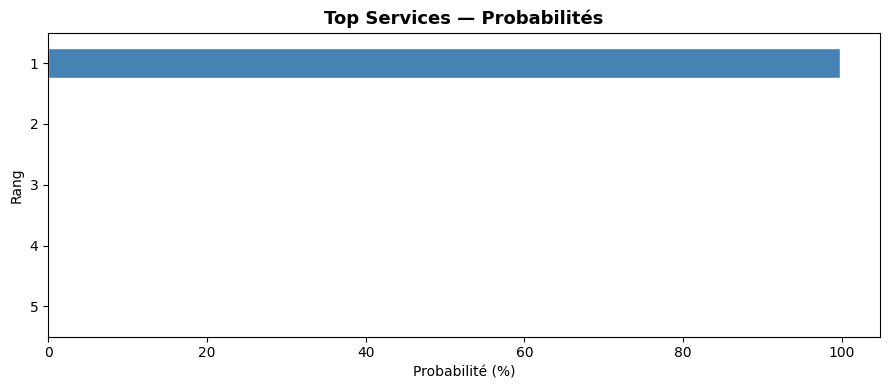

In [ ]:
# ── ✏️ TON PROPRE PATIENT — modifie ici ──────────────────────────────────────
mon_patient = predire_patient(
    age=24,
    sexe='Feminin',
    visite='Première visite',
    lieu='Kadiogo',
    motif_consultation='MC(Motif de Consultation): controle post partum tardif S6 par césarienne le 13/03/2024 G3 P1, 1 EV Pas de palintes Retour de couches effectif',
    examen_clinique="BEG, conj(Conjonctives) colorées TA(Tension Artérielle): 135/95 Poids 60 kg Pouls(C’est pas un sigle) 102 T(Température)°36°3 Seins RAS(Rien à Signaler) Bonne cicatrisation, abdomen souple indolore Utérus de taille gynéco TV: vulve propre, vagin souple, col(Colorées) fermé, utérus de taille normale Au total: post partum tardif sans particularité CAT(Conduite à Tenir): rassurer Counseling PF "
    "pas de signes de déshydratation, "
    "température : 37°C, PC : 38 cm, PT : 38 cm.",
    top_n=5
)

print(f"🔵 Domaine  : {mon_patient['domaine']}")
print(f"🟢 Service  : {mon_patient['service']}")
print(f"🔴 ESI      : {mon_patient['esi']}")
print()

# Visualisation top services
fig, ax = plt.subplots(figsize=(9, 4))
mon_patient['top_services'].plot(
    kind='barh', y='Probabilité (%)', ax=ax,
    color='steelblue', edgecolor='white', legend=False
)
ax.set_title('Top Services — Probabilités', fontweight='bold', fontsize=13)
ax.set_xlabel('Probabilité (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

🔵 Domaine  : Pédiatrie
🟢 Service  : Pédiatrie
🔴 ESI      : 5.0



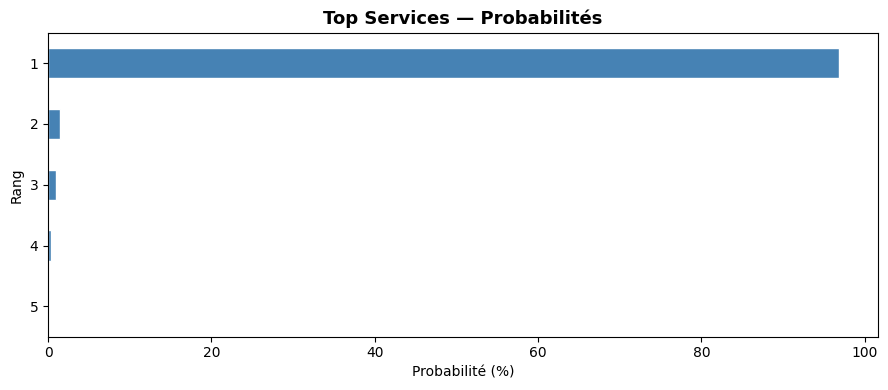

In [ ]:
# ── ✏️ EXEMPLE PATIENT — FORMULAIRE TRIAGE IA ─────────────────────────────

mon_patient = predire_patient(

    age=4,

    sexe='Masculin',

    visite='Première visite',

    lieu='Houet',

    motif_consultation=
    'Fièvre depuis 3 jours, toux, rhinorrhée, fatigue',

    examen_clinique=
    'Bon état général, muqueuses humides, bon état de conscience, '
    'auscultation normale, abdomen souple, température 39.1°C, '
    'fréquence cardiaque 110 bpm, saturation O2 98%, '
    'fréquence respiratoire 24/min',

    top_n=5
)

print(f"🔵 Domaine  : {mon_patient['domaine']}")
print(f"🟢 Service  : {mon_patient['service']}")
print(f"🔴 ESI      : {mon_patient['esi']}")
print()

# ── Visualisation top services ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))

mon_patient['top_services'].plot(
    kind='barh',
    y='Probabilité (%)',
    ax=ax,
    color='steelblue',
    edgecolor='white',
    legend=False
)

ax.set_title(
    'Top Services — Probabilités',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Probabilité (%)')

ax.invert_yaxis()

plt.tight_layout()

plt.show()

## 📋 12. Résumé de l'architecture

### Chaîne hiérarchique de prédiction

```
Données patient (âge, sexe, visite, lieu, texte clinique)
         │
         ▼
   [TF-IDF bigrammes + OHE + numériques]
         │
         ▼
   ┌─────────────────────┐
   │  Étape 1 : DOMAINE  │ ← RF / XGB / DNN
   └─────────────────────┘
         │  + probabilités domaine
         ▼
   ┌─────────────────────┐
   │  Étape 2 : SERVICE  │ ← RF / XGB / DNN
   └─────────────────────┘
         │  + probabilités service
         ▼
   ┌─────────────────────┐
   │   Étape 3 : ESI     │ ← RF / XGB / DNN
   └─────────────────────┘
```

### Architecture DNN (chaque étape)

| Couche | Unités | Activation | Régularisation |
|---|---|---|---|
| Dense 1 | 512 | ReLU | BatchNorm + Dropout 40% |
| Dense 2 | 256 | ReLU | BatchNorm + Dropout 35% |
| Dense 3 | 128 | ReLU | BatchNorm + Dropout 30% |
| Sortie  | n_classes | Softmax | — |

**Optimiseur :** Adam · **Early stopping :** patience=8 · **ReduceLROnPlateau :** patience=4

### 🚀 Pistes d'amélioration
- **SMOTE / class_weight** pour les services rares (< 30 patients)
- **Optuna** pour optimiser les hyperparamètres XGBoost et DNN
- **CamemBERT** (BERT en français) pour l'encodage du texte clinique
- **Calibration des probabilités** (CalibratedClassifierCV) pour des scores plus fiables
- **API FastAPI** pour déploiement en production